# Two Moons — Laplace Approximation
Classic toy example for uncertainty quantification. Small 2D dataset, tiny MLP, `all` weights — runs in seconds.

In [3]:
# Run once
!pip install -q torch torchvision laplace-torch scikit-learn matplotlib
!pip install -q "curvlinops-for-pytorch<3.0"

In [4]:
# 1. Install laplace-torch first
!pip install laplace-torch

# 2. Force NumPy back to the 2.x version Colab wants
!pip install "numpy>=2.0" --upgrade

# 3. Re-install/Upgrade the main conflicting packages
!pip install --upgrade jax jaxlib

  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ml 0.6.1 requires enum34, which is not installed.
azureml-automl-dnn-nlp 1.61.0 requires torch==2.2.2, but you have torch 2.9.1 which is incompatible.
azureml-automl-runtime 1.61.0 requires numpy<=1.23.5,>=1.16.0; python_version >= "3.8", but you have numpy 2.2.6 which is incompatible.
azureml-automl-runtime 1.61.0 requires scipy<=1.11.0,>=1.0.0, but you have scipy 1.15.3 which is incompatible.
azureml-datadrift 1.61.0 requires matplotlib<=3.6.3,>=3.0.2, but you hav

## 1. Imports

In [5]:
%pip install "numpy<2" pandas

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 3.8.1 requires mlflow-skinny==3.8.1, but you have mlflow-skinny 3.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from laplace import Laplace

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Generate Two Moons dataset

Train: 6000  Val: 2000  Test: 2000


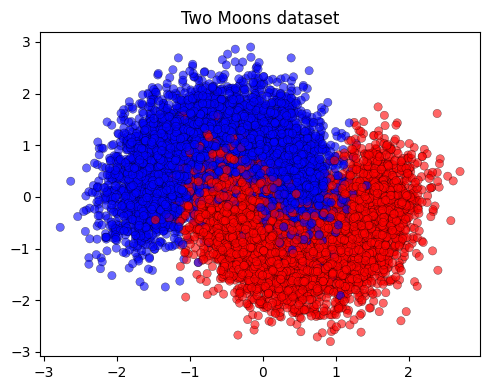

In [4]:
np.random.seed(42)
torch.manual_seed(42)

X, y = make_moons(n_samples=10000, noise=0.3, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

def to_tensors(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

train_ds = to_tensors(X_train, y_train)
val_ds   = to_tensors(X_val,   y_val)
test_ds  = to_tensors(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

# Visualise raw data
plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6, edgecolors='k', linewidths=0.3)
plt.title('Two Moons dataset')
plt.tight_layout()
plt.show()

## 3. Define a tiny MLP

In [5]:
class TinyMLP(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),   # raw logits
        )
    def forward(self, x):
        return self.net(x)

model = TinyMLP(hidden=64).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')
print(model)

Parameters: 4,482
TinyMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 4. Train the MAP model

MAP test accuracy: 92.2%


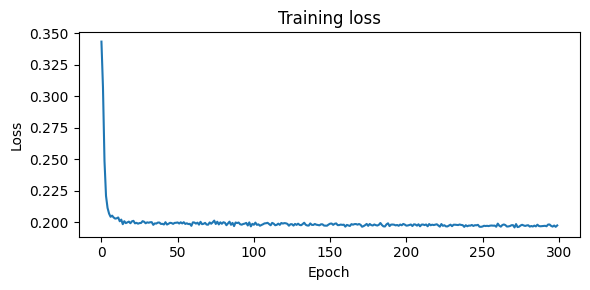

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS = 300
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(train_ds))

model.eval()

# Test accuracy
correct = total = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total   += len(yb)

print(f'MAP test accuracy: {100*correct/total:.1f}%')

plt.figure(figsize=(6, 3))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.tight_layout()
plt.show()

## 5. Helper: plot decision boundary

In [7]:
def plot_boundary(predict_fn, X_data, y_data, title, ax=None):
    """predict_fn: takes (N,2) numpy array, returns (N,) prob of class 1"""
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    # Uncertainty = how far from 0.5 the probability is (inverted)
    uncertainty = 1 - 2 * np.abs(probs - 0.5)

    cf = ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8,
                     vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data,
               cmap='bwr', edgecolors='k', linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    return cf

print('Helper defined.')

Helper defined.


## 6. MAP predictions

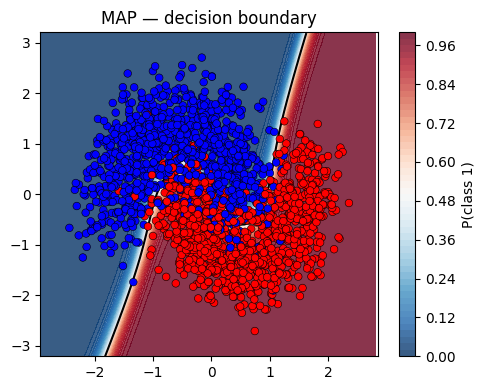

In [8]:
def map_predict(X_np):
    x = torch.tensor(X_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)
    return probs[:, 1].cpu().numpy()

fig, ax = plt.subplots(figsize=(5, 4))
cf = plot_boundary(map_predict, X_test, y_test, 'MAP — decision boundary', ax=ax)
plt.colorbar(cf, ax=ax, label='P(class 1)')
plt.tight_layout()
plt.show()

## 7. Fit Laplace approximation (all weights)

In [9]:
la = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='diag'
)
la.fit(train_loader)
print('Laplace fitted.')

la.optimize_prior_precision(
    method='gridsearch',
    pred_type='glm',
    link_approx='probit',
    val_loader=val_loader
)
print(f'Optimised prior precision: {la.prior_precision.item():.4f}')

Laplace fitted.


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/laplace/baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(


Optimised prior precision: 10000.0000


## 8. Laplace predictions

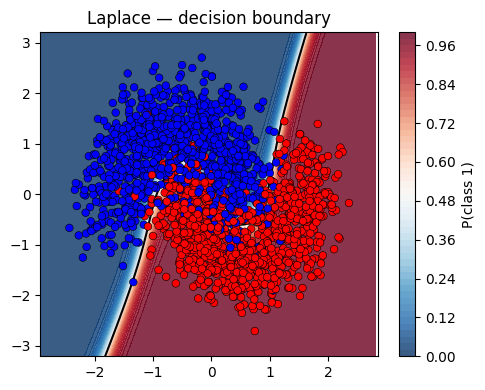

In [10]:
def la_predict(X_np, batch_size=256):
    results = []
    x_tensor = torch.tensor(X_np, dtype=torch.float32)
    for i in range(0, len(x_tensor), batch_size):
        batch = x_tensor[i:i+batch_size].to(device)
        with torch.no_grad():
            probs = la(batch, pred_type='glm', link_approx='probit')
        results.append(probs[:, 1].cpu())
    return torch.cat(results).numpy()

fig, ax = plt.subplots(figsize=(5, 4))
cf = plot_boundary(la_predict, X_test, y_test, 'Laplace — decision boundary', ax=ax)
plt.colorbar(cf, ax=ax, label='P(class 1)')
plt.tight_layout()
plt.show()

## 9. Side-by-side comparison

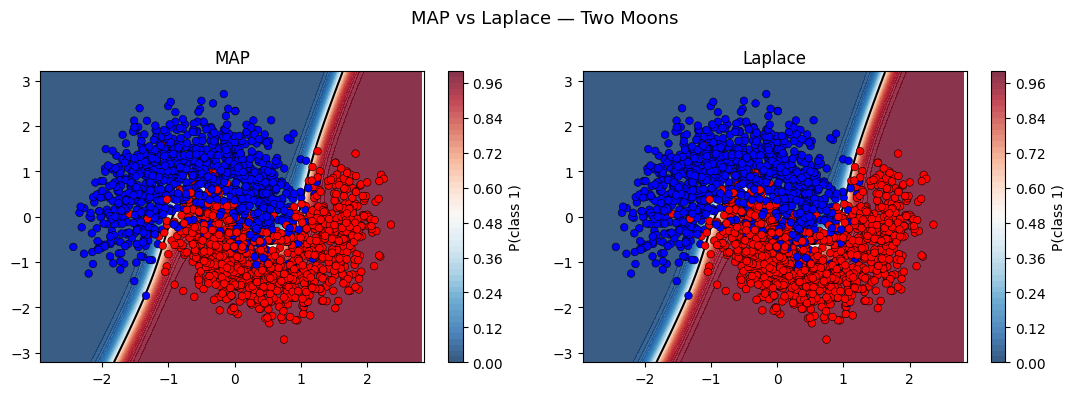

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf1 = plot_boundary(map_predict, X_test, y_test, 'MAP', axes[0])
cf2 = plot_boundary(la_predict,  X_test, y_test, 'Laplace',  axes[1])

plt.colorbar(cf1, ax=axes[0], label='P(class 1)')
plt.colorbar(cf2, ax=axes[1], label='P(class 1)')
plt.suptitle('MAP vs Laplace — Two Moons', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Uncertainty map
Directly visualise where the model is uncertain (close to 0.5 probability).

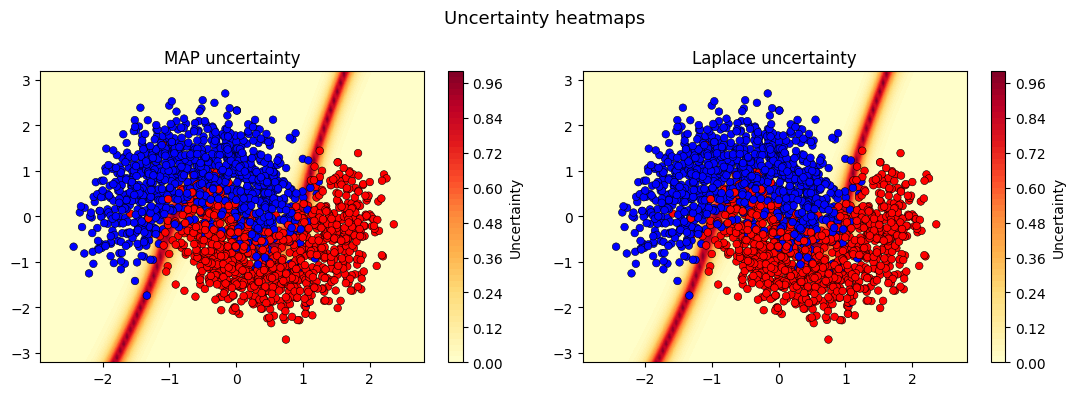

In [12]:
def uncertainty_map(predict_fn, X_data, y_data, title, ax):
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_fn(grid).reshape(xx.shape)
    uncertainty = 1 - 2 * np.abs(probs - 0.5)  # 1 = max uncertainty, 0 = certain

    cf = ax.contourf(xx, yy, uncertainty, levels=50, cmap='YlOrRd', vmin=0, vmax=1)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data,
               cmap='bwr', edgecolors='k', linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)
    return cf

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cf1 = uncertainty_map(map_predict, X_test, y_test, 'MAP uncertainty', axes[0])
cf2 = uncertainty_map(la_predict,  X_test, y_test, 'Laplace uncertainty', axes[1])
plt.colorbar(cf1, ax=axes[0], label='Uncertainty')
plt.colorbar(cf2, ax=axes[1], label='Uncertainty')
plt.suptitle('Uncertainty heatmaps', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# ── Refit with marginal likelihood optimization ──────────────────────────────
la_marglik = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='diag'
)
la_marglik.fit(train_loader)
print('Laplace fitted.')

la_marglik.optimize_prior_precision(method='marglik')
print(f'Prior precision (marglik): {la_marglik.prior_precision.item():.4f}')

Laplace fitted.
Prior precision (marglik): 8.5883


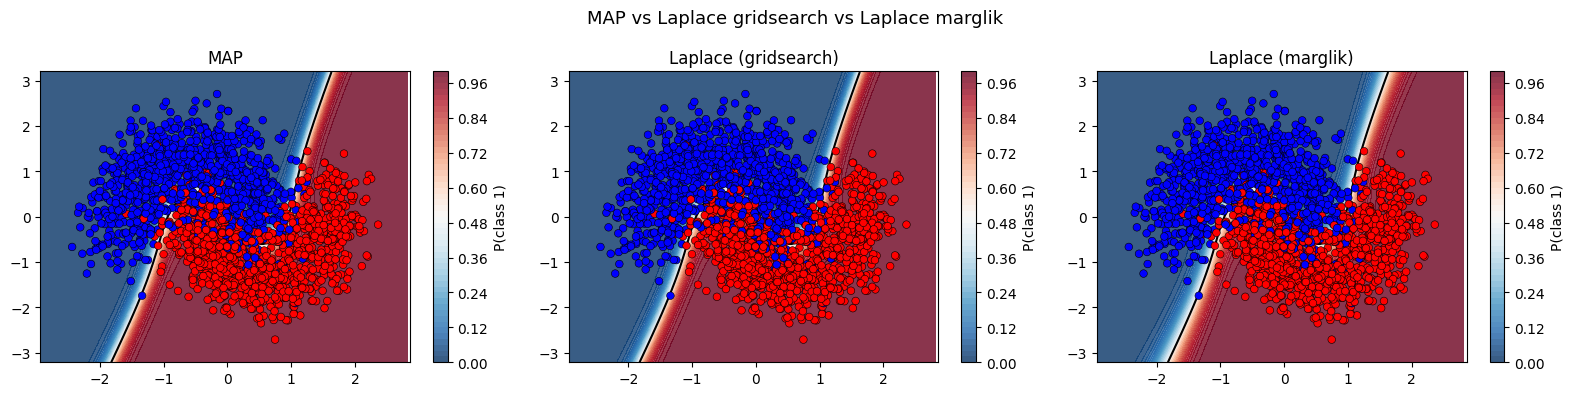

In [14]:
# ── Boundary plots ───────────────────────────────────────────────────────────
def la_marglik_predict(X_np, batch_size=256):
    results = []
    x_tensor = torch.tensor(X_np, dtype=torch.float32)
    for i in range(0, len(x_tensor), batch_size):
        batch = x_tensor[i:i+batch_size].to(device)
        with torch.no_grad():
            probs = la_marglik(batch, pred_type='glm', link_approx='probit')
        results.append(probs[:, 1].cpu())
    return torch.cat(results).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cf0 = plot_boundary(map_predict,        X_test, y_test, 'MAP',                        axes[0])
cf1 = plot_boundary(la_predict,         X_test, y_test, f'Laplace (gridsearch)',       axes[1])
cf2 = plot_boundary(la_marglik_predict, X_test, y_test, f'Laplace (marglik)',          axes[2])

for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')

plt.suptitle('MAP vs Laplace gridsearch vs Laplace marglik', fontsize=13)
plt.tight_layout()
plt.show()

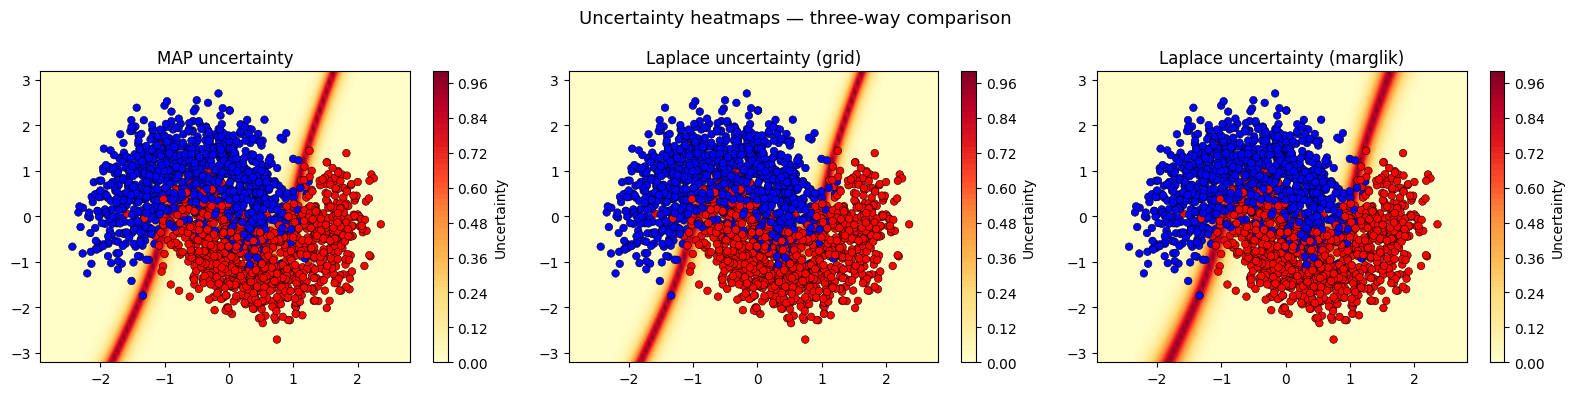

In [15]:
# ── Uncertainty heatmaps ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cf0 = uncertainty_map(map_predict,        X_test, y_test, 'MAP uncertainty',             axes[0])
cf1 = uncertainty_map(la_predict,         X_test, y_test, 'Laplace uncertainty (grid)',  axes[1])
cf2 = uncertainty_map(la_marglik_predict, X_test, y_test, 'Laplace uncertainty (marglik)', axes[2])

for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')

plt.suptitle('Uncertainty heatmaps — three-way comparison', fontsize=13)
plt.tight_layout()
plt.show()

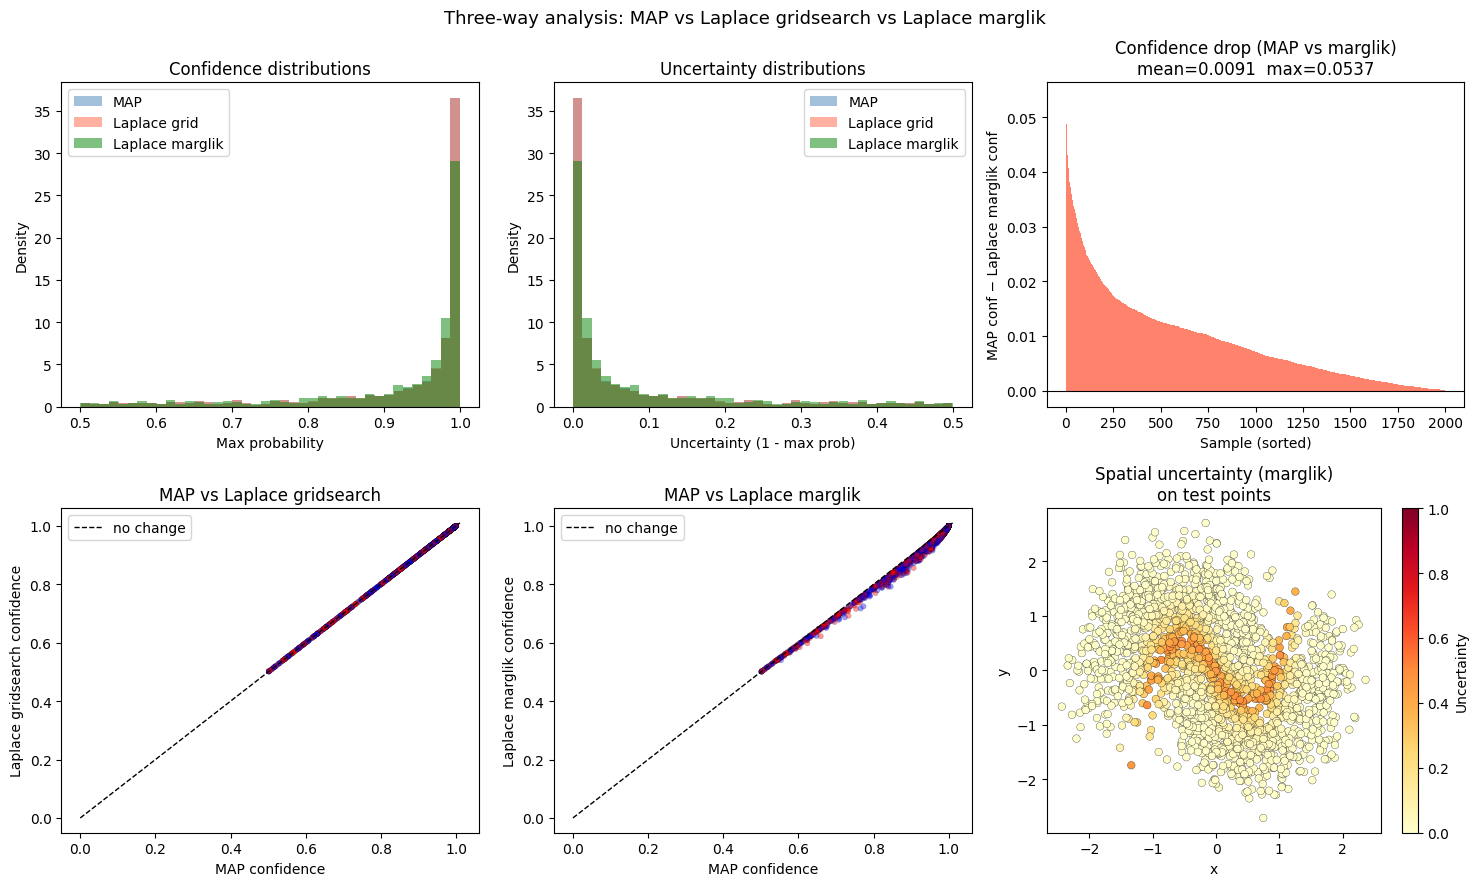

Prior precision — gridsearch: 10000.0000
Prior precision — marglik:    8.5883
MAP accuracy:          92.2%
Laplace grid accuracy: 92.2%
Laplace marglik acc:   92.2%


In [16]:
# ── Per-sample analysis: all three side by side ──────────────────────────────
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

# MAP probs
with torch.no_grad():
    map_probs_test = F.softmax(model(X_test_t), dim=1).cpu().numpy()

# Laplace gridsearch probs
la_gs_list = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        la_gs_list.append(la(batch, pred_type='glm', link_approx='probit').cpu())
la_gs_probs = torch.cat(la_gs_list).numpy()

# Laplace marglik probs
la_ml_list = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        la_ml_list.append(la_marglik(batch, pred_type='glm', link_approx='probit').cpu())
la_ml_probs = torch.cat(la_ml_list).numpy()

map_conf = map_probs_test.max(axis=1)
gs_conf  = la_gs_probs.max(axis=1)
ml_conf  = la_ml_probs.max(axis=1)

map_unc  = 1 - map_conf
gs_unc   = 1 - gs_conf
ml_unc   = 1 - ml_conf

map_preds = map_probs_test.argmax(axis=1)
gs_preds  = la_gs_probs.argmax(axis=1)
ml_preds  = la_ml_probs.argmax(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Confidence distributions
axes[0,0].hist(map_conf, bins=40, alpha=0.5, label='MAP',              color='steelblue', density=True)
axes[0,0].hist(gs_conf,  bins=40, alpha=0.5, label='Laplace grid',     color='tomato',    density=True)
axes[0,0].hist(ml_conf,  bins=40, alpha=0.5, label='Laplace marglik',  color='green',     density=True)
axes[0,0].set_xlabel('Max probability')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Confidence distributions')
axes[0,0].legend()

# 2. Uncertainty distributions
axes[0,1].hist(map_unc, bins=40, alpha=0.5, label='MAP',              color='steelblue', density=True)
axes[0,1].hist(gs_unc,  bins=40, alpha=0.5, label='Laplace grid',     color='tomato',    density=True)
axes[0,1].hist(ml_unc,  bins=40, alpha=0.5, label='Laplace marglik',  color='green',     density=True)
axes[0,1].set_xlabel('Uncertainty (1 - max prob)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Uncertainty distributions')
axes[0,1].legend()

# 3. Per-sample confidence drop: MAP vs marglik
diff_ml = map_conf - ml_conf
sorted_diff = np.sort(diff_ml)[::-1]
axes[0,2].bar(range(len(sorted_diff)), sorted_diff,
              color=np.where(sorted_diff > 0, 'tomato', 'steelblue'),
              width=1.0, alpha=0.8)
axes[0,2].axhline(0, color='k', linewidth=0.8)
axes[0,2].set_xlabel('Sample (sorted)')
axes[0,2].set_ylabel('MAP conf − Laplace marglik conf')
axes[0,2].set_title(f'Confidence drop (MAP vs marglik)\nmean={diff_ml.mean():.4f}  max={diff_ml.max():.4f}')

# 4. Scatter: MAP vs gridsearch
axes[1,0].scatter(map_conf, gs_conf, alpha=0.4, s=15,
                  c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
lims = [0, 1.01]
axes[1,0].plot(lims, lims, 'k--', linewidth=1, label='no change')
axes[1,0].set_xlabel('MAP confidence')
axes[1,0].set_ylabel('Laplace gridsearch confidence')
axes[1,0].set_title('MAP vs Laplace gridsearch')
axes[1,0].legend()

# 5. Scatter: MAP vs marglik
axes[1,1].scatter(map_conf, ml_conf, alpha=0.4, s=15,
                  c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[1,1].plot(lims, lims, 'k--', linewidth=1, label='no change')
axes[1,1].set_xlabel('MAP confidence')
axes[1,1].set_ylabel('Laplace marglik confidence')
axes[1,1].set_title('MAP vs Laplace marglik')
axes[1,1].legend()

# 6. Spatial uncertainty: marglik on test points
sc = axes[1,2].scatter(X_test[:, 0], X_test[:, 1],
                        c=ml_unc, cmap='YlOrRd', s=30,
                        edgecolors='k', linewidths=0.2, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1,2], label='Uncertainty')
axes[1,2].set_title('Spatial uncertainty (marglik)\non test points')
axes[1,2].set_xlabel('x')
axes[1,2].set_ylabel('y')

plt.suptitle('Three-way analysis: MAP vs Laplace gridsearch vs Laplace marglik', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Prior precision — gridsearch: {la.prior_precision.item():.4f}')
print(f'Prior precision — marglik:    {la_marglik.prior_precision.item():.4f}')
print(f'MAP accuracy:          {(map_preds == y_test).mean()*100:.1f}%')
print(f'Laplace grid accuracy: {(gs_preds  == y_test).mean()*100:.1f}%')
print(f'Laplace marglik acc:   {(ml_preds  == y_test).mean()*100:.1f}%')

In [17]:
# ── Refit with marginal likelihood optimization and full hessian ──────────────────────────────
la_marglik_full = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='full'
)
la_marglik_full.fit(train_loader)
print('Laplace fitted.')

la_marglik_full.optimize_prior_precision(method='marglik')
print(f'Prior precision (marglik_full): {la_marglik_full.prior_precision.item():.4f}')

Laplace fitted.
Prior precision (marglik_full): 0.5155


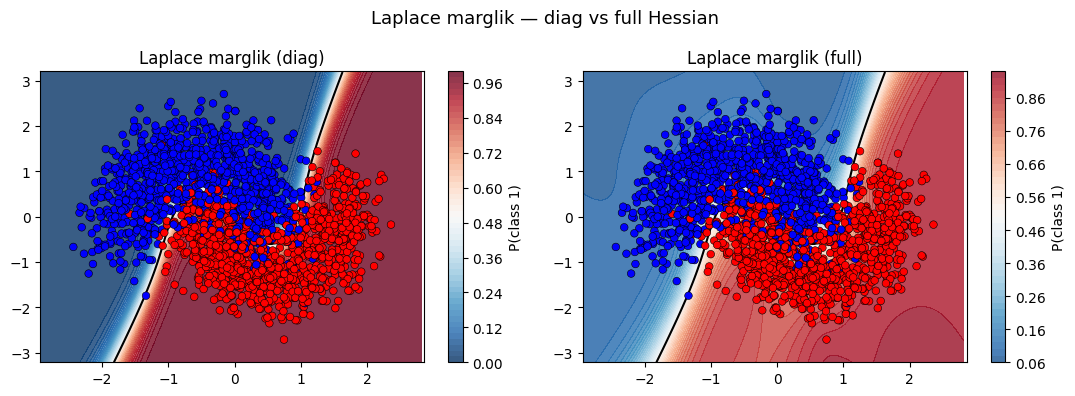

In [18]:
# ── Boundary plots ───────────────────────────────────────────────────────────
def la_marglik_full_predict(X_np, batch_size=256):
    results = []
    x_tensor = torch.tensor(X_np, dtype=torch.float32)
    for i in range(0, len(x_tensor), batch_size):
        batch = x_tensor[i:i+batch_size].to(device)
        with torch.no_grad():
            probs = la_marglik_full(batch, pred_type='glm', link_approx='probit')
        results.append(probs[:, 1].cpu())
    return torch.cat(results).numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf0 = plot_boundary(la_marglik_predict,      X_test, y_test, 'Laplace marglik (diag)', axes[0])
cf1 = plot_boundary(la_marglik_full_predict, X_test, y_test, 'Laplace marglik (full)', axes[1])

for cf, ax in zip([cf0, cf1], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')

plt.suptitle('Laplace marglik — diag vs full Hessian', fontsize=13)
plt.tight_layout()
plt.show()

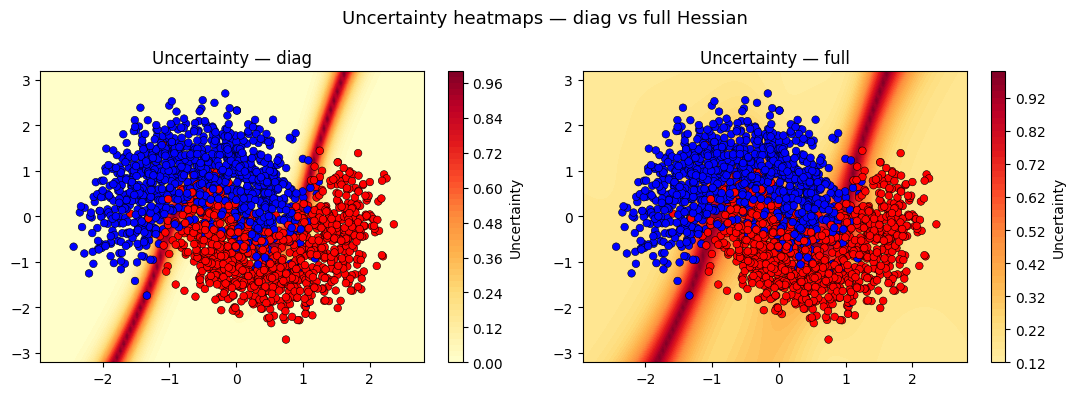

In [19]:
# ── Uncertainty heatmaps ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cf0 = uncertainty_map(la_marglik_predict,      X_test, y_test, 'Uncertainty — diag', axes[0])
cf1 = uncertainty_map(la_marglik_full_predict, X_test, y_test, 'Uncertainty — full', axes[1])

for cf, ax in zip([cf0, cf1], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')

plt.suptitle('Uncertainty heatmaps — diag vs full Hessian', fontsize=13)
plt.tight_layout()
plt.show()

Prior precision diag: 8.5883
Prior precision full: 0.5155
Diag accuracy: 92.2%
Full accuracy: 92.2%


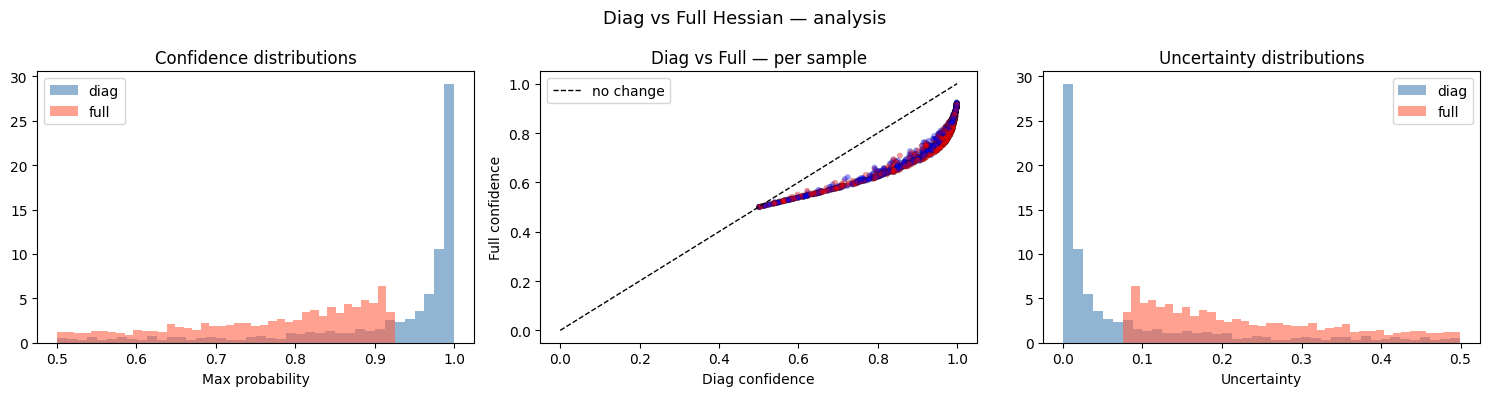

In [20]:
# ── Per-sample comparison ─────────────────────────────────────────────────────
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

diag_list = []
full_list  = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        diag_list.append(la_marglik(batch,      pred_type='glm', link_approx='probit').cpu())
        full_list.append(la_marglik_full(batch, pred_type='glm', link_approx='probit').cpu())

diag_probs = torch.cat(diag_list).numpy()
full_probs = torch.cat(full_list).numpy()

diag_conf = diag_probs.max(axis=1)
full_conf = full_probs.max(axis=1)
diag_unc  = 1 - diag_conf
full_unc  = 1 - full_conf

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confidence distributions
axes[0].hist(diag_conf, bins=40, alpha=0.6, label='diag', color='steelblue', density=True)
axes[0].hist(full_conf, bins=40, alpha=0.6, label='full', color='tomato',    density=True)
axes[0].set_xlabel('Max probability')
axes[0].set_title('Confidence distributions')
axes[0].legend()

# Scatter diag vs full confidence
axes[1].scatter(diag_conf, full_conf, alpha=0.4, s=15,
                c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='no change')
axes[1].set_xlabel('Diag confidence')
axes[1].set_ylabel('Full confidence')
axes[1].set_title('Diag vs Full — per sample')
axes[1].legend()

# Uncertainty distributions
axes[2].hist(diag_unc, bins=40, alpha=0.6, label='diag', color='steelblue', density=True)
axes[2].hist(full_unc, bins=40, alpha=0.6, label='full', color='tomato',    density=True)
axes[2].set_xlabel('Uncertainty')
axes[2].set_title('Uncertainty distributions')
axes[2].legend()

print(f'Prior precision diag: {la_marglik.prior_precision.item():.4f}')
print(f'Prior precision full: {la_marglik_full.prior_precision.item():.4f}')
print(f'Diag accuracy: {(diag_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')
print(f'Full accuracy: {(full_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')

plt.suptitle('Diag vs Full Hessian — analysis', fontsize=13)
plt.tight_layout()
plt.show()

Laplace fitted (kron).
Prior precision (marglik_kron): 1.4092


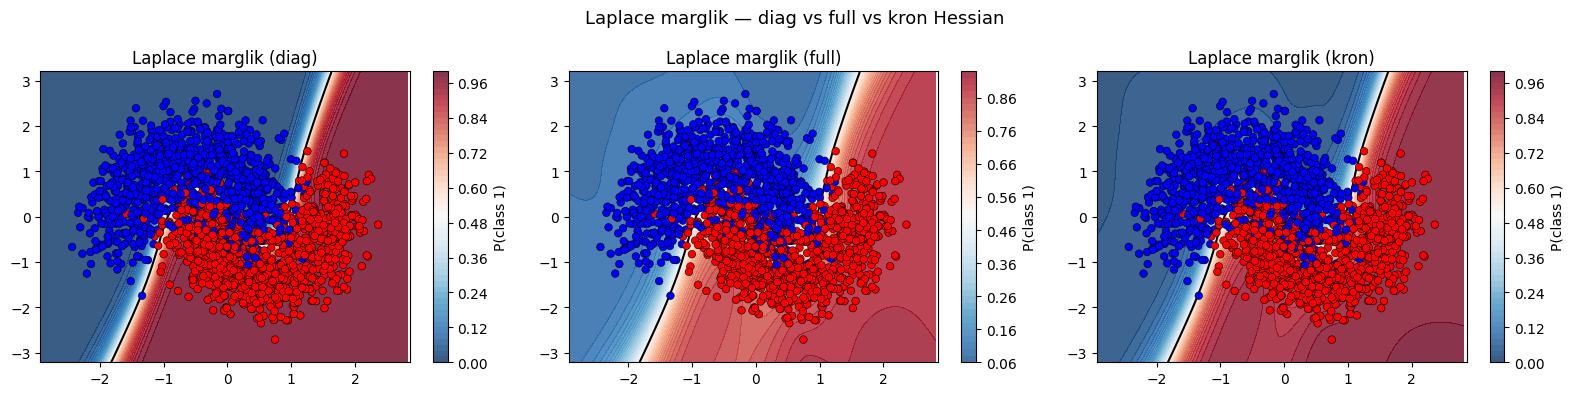

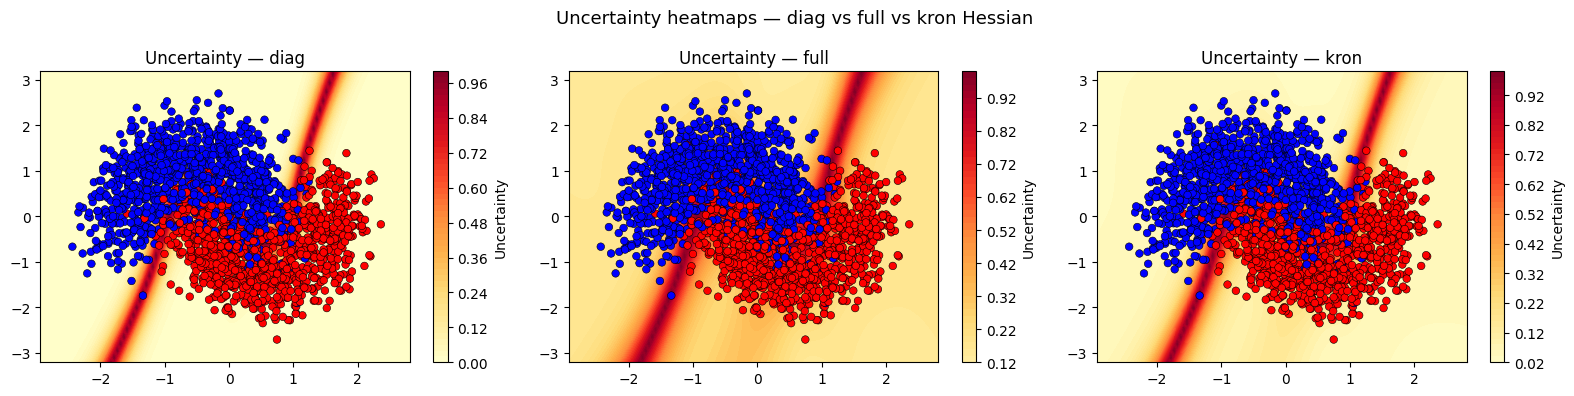

Prior precision diag: 8.5883
Prior precision full: 0.5155
Prior precision kron: 1.4092
Diag accuracy: 92.2%
Full accuracy: 92.2%
Kron accuracy: 92.2%


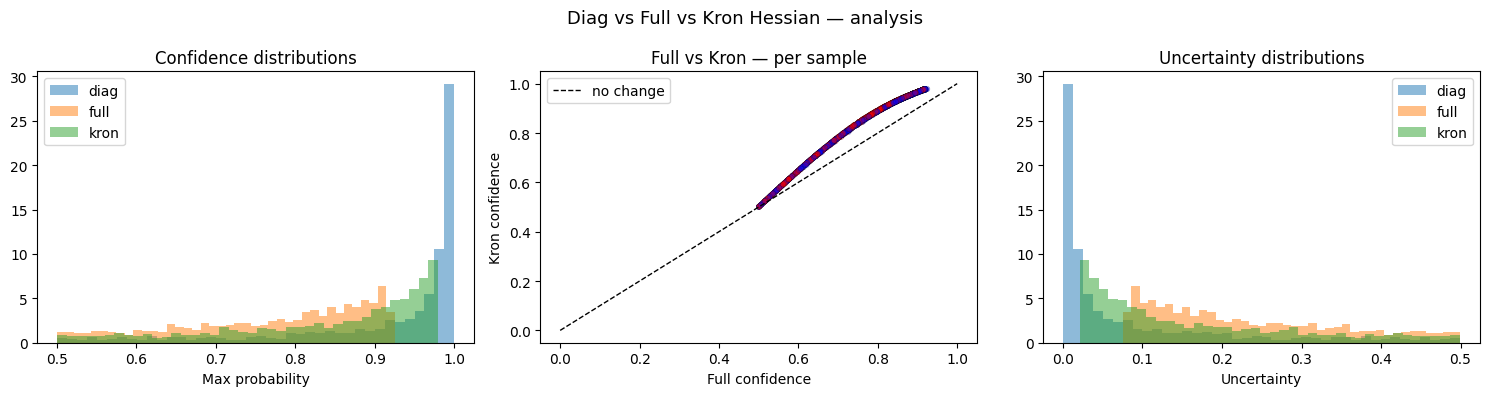

In [21]:
# ── Refit with marginal likelihood optimization and KFAC (kron) hessian ──────────────────────────────
la_marglik_kron = Laplace(
    model,
    'classification',
    subset_of_weights='all',
    hessian_structure='kron'
)
la_marglik_kron.fit(train_loader)
print('Laplace fitted (kron).')

la_marglik_kron.optimize_prior_precision(method='marglik')
print(f'Prior precision (marglik_kron): {la_marglik_kron.prior_precision.item():.4f}')

# ── Boundary plots: Diag vs Full vs Kron ───────────────────────────────────────────────────────────
def la_marglik_kron_predict(X_np, batch_size=256):
    results = []
    x_tensor = torch.tensor(X_np, dtype=torch.float32)
    for i in range(0, len(x_tensor), batch_size):
        batch = x_tensor[i:i+batch_size].to(device)
        with torch.no_grad():
            probs = la_marglik_kron(batch, pred_type='glm', link_approx='probit')
        results.append(probs[:, 1].cpu())
    return torch.cat(results).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cf0 = plot_boundary(la_marglik_predict,      X_test, y_test, 'Laplace marglik (diag)', axes[0])
cf1 = plot_boundary(la_marglik_full_predict, X_test, y_test, 'Laplace marglik (full)', axes[1])
cf2 = plot_boundary(la_marglik_kron_predict, X_test, y_test, 'Laplace marglik (kron)', axes[2])
for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')
plt.suptitle('Laplace marglik — diag vs full vs kron Hessian', fontsize=13)
plt.tight_layout()
plt.show()

# ── Uncertainty heatmaps: Diag vs Full vs Kron ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cf0 = uncertainty_map(la_marglik_predict,      X_test, y_test, 'Uncertainty — diag', axes[0])
cf1 = uncertainty_map(la_marglik_full_predict, X_test, y_test, 'Uncertainty — full', axes[1])
cf2 = uncertainty_map(la_marglik_kron_predict, X_test, y_test, 'Uncertainty — kron', axes[2])
for cf, ax in zip([cf0, cf1, cf2], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')
plt.suptitle('Uncertainty heatmaps — diag vs full vs kron Hessian', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-sample comparison: Diag vs Full vs Kron ─────────────────────────────────────────────────────
kron_list = []
for i in range(0, len(X_test_t), 64):
    batch = X_test_t[i:i+64]
    with torch.no_grad():
        kron_list.append(la_marglik_kron(batch, pred_type='glm', link_approx='probit').cpu())

kron_probs = torch.cat(kron_list).numpy()
kron_conf = kron_probs.max(axis=1)
kron_unc  = 1 - kron_conf

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(diag_conf, bins=40, alpha=0.5, label='diag', density=True)
axes[0].hist(full_conf, bins=40, alpha=0.5, label='full', density=True)
axes[0].hist(kron_conf, bins=40, alpha=0.5, label='kron', density=True)
axes[0].set_xlabel('Max probability')
axes[0].set_title('Confidence distributions')
axes[0].legend()

axes[1].scatter(full_conf, kron_conf, alpha=0.4, s=15,
                c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='no change')
axes[1].set_xlabel('Full confidence')
axes[1].set_ylabel('Kron confidence')
axes[1].set_title('Full vs Kron — per sample')
axes[1].legend()

axes[2].hist(diag_unc, bins=40, alpha=0.5, label='diag', density=True)
axes[2].hist(full_unc, bins=40, alpha=0.5, label='full', density=True)
axes[2].hist(kron_unc, bins=40, alpha=0.5, label='kron', density=True)
axes[2].set_xlabel('Uncertainty')
axes[2].set_title('Uncertainty distributions')
axes[2].legend()

print(f'Prior precision diag: {la_marglik.prior_precision.item():.4f}')
print(f'Prior precision full: {la_marglik_full.prior_precision.item():.4f}')
print(f'Prior precision kron: {la_marglik_kron.prior_precision.item():.4f}')
print(f'Diag accuracy: {(diag_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')
print(f'Full accuracy: {(full_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')
print(f'Kron accuracy: {(kron_probs.argmax(axis=1) == y_test).mean()*100:.1f}%')

plt.suptitle('Diag vs Full vs Kron Hessian — analysis', fontsize=13)
plt.tight_layout()
plt.show()

LL Diag prior precision: 11.3648
LL Kron prior precision: 2.0719
LL Full prior precision: 1.8151


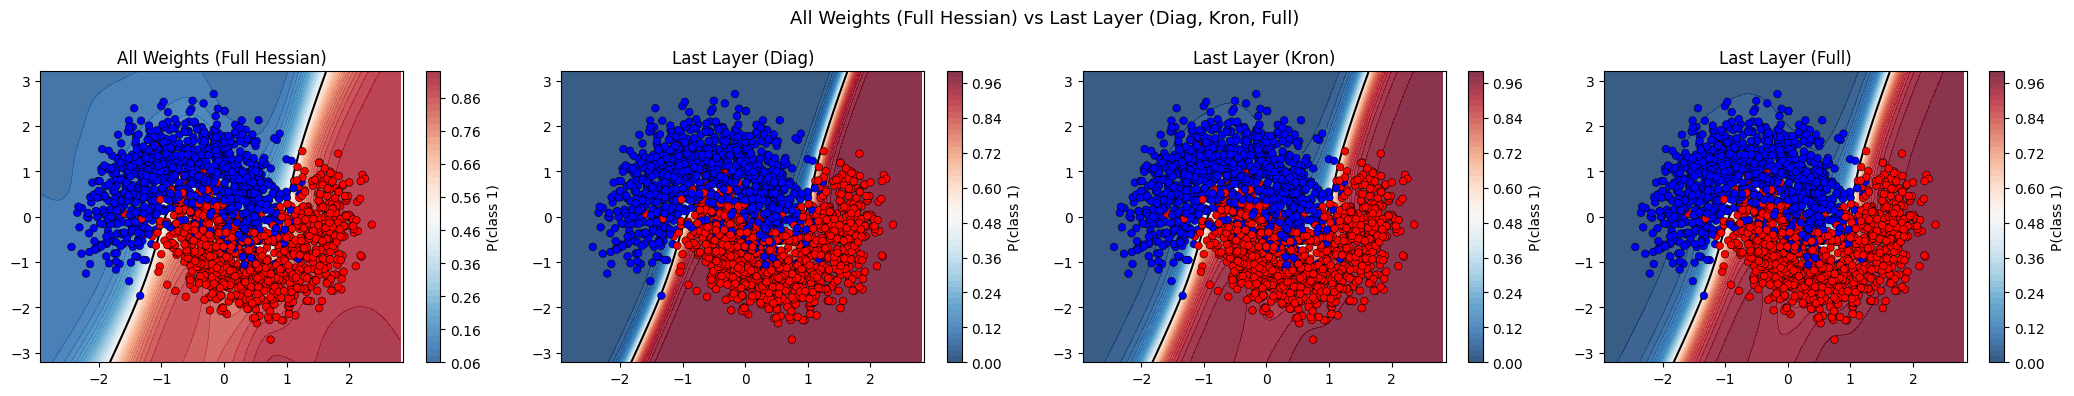

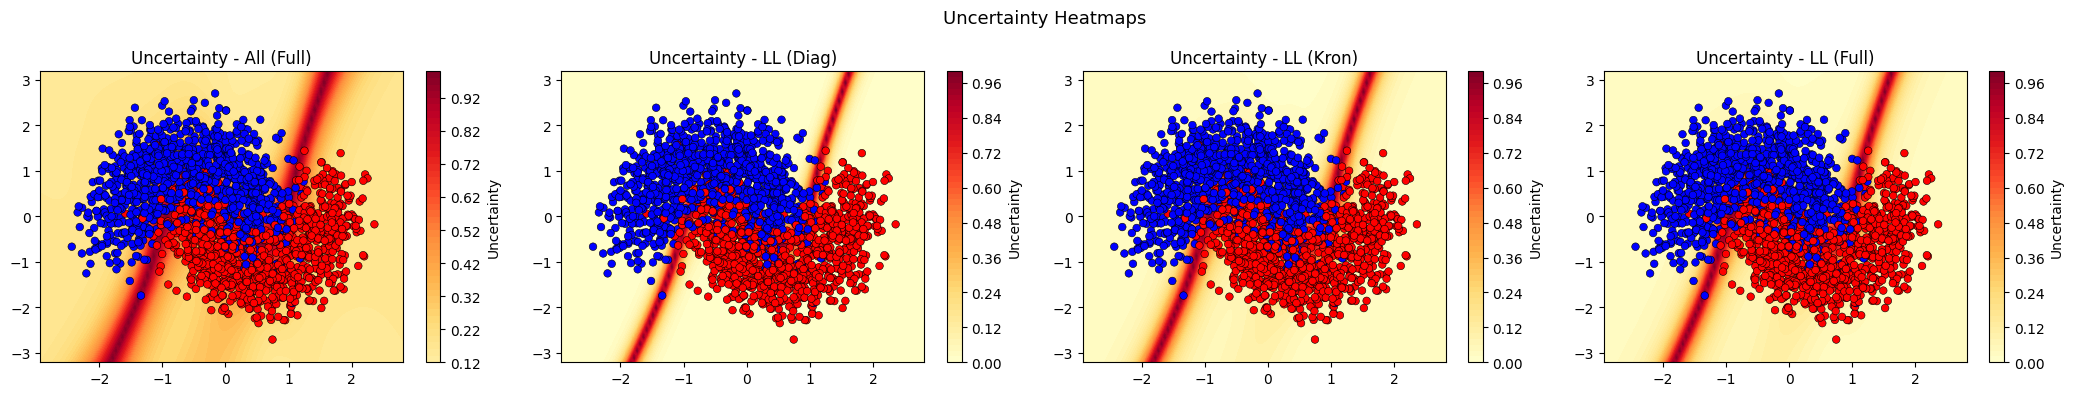

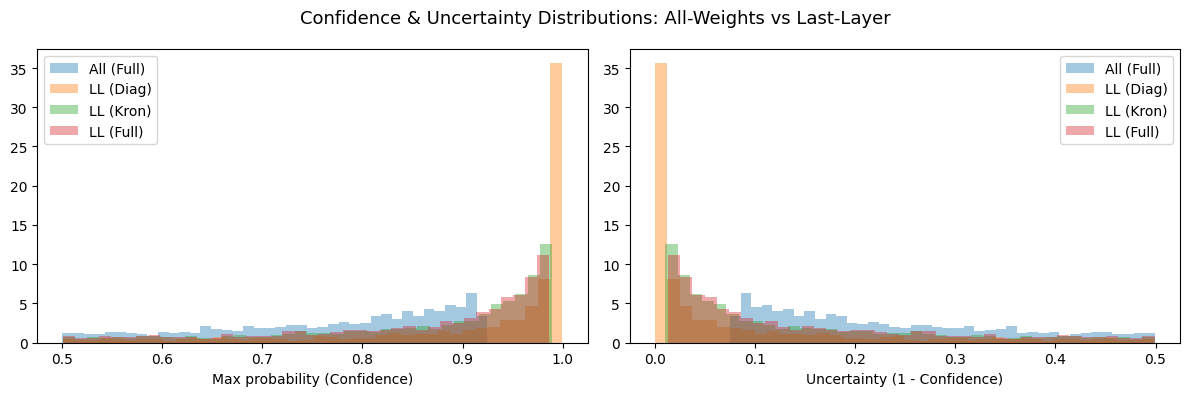

All Weights Full Hessian Accuracy: 92.2%
Last Layer Diag Accuracy:          92.2%
Last Layer Kron Accuracy:          92.2%
Last Layer Full Accuracy:          92.2%


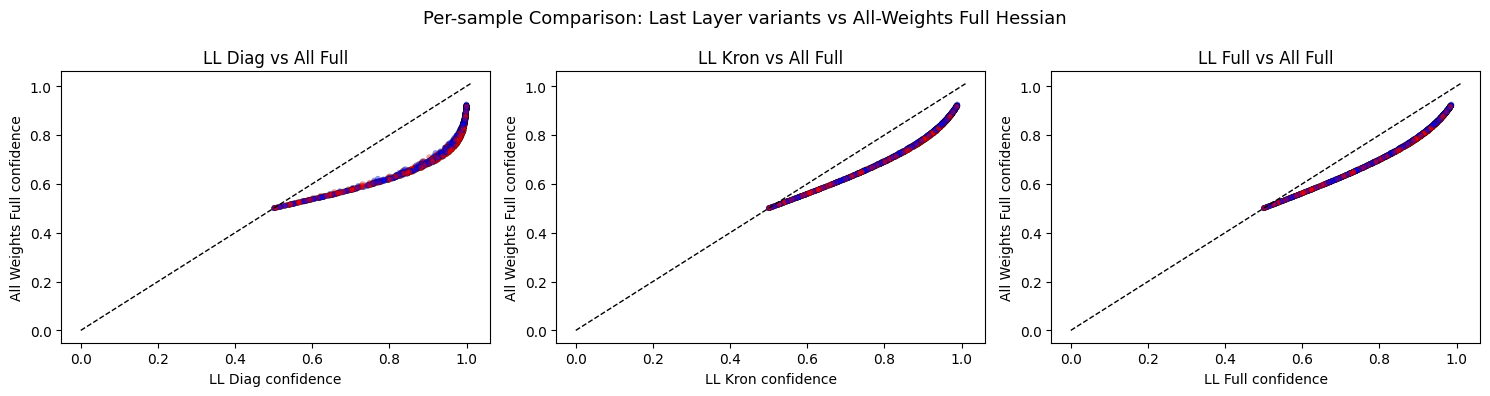

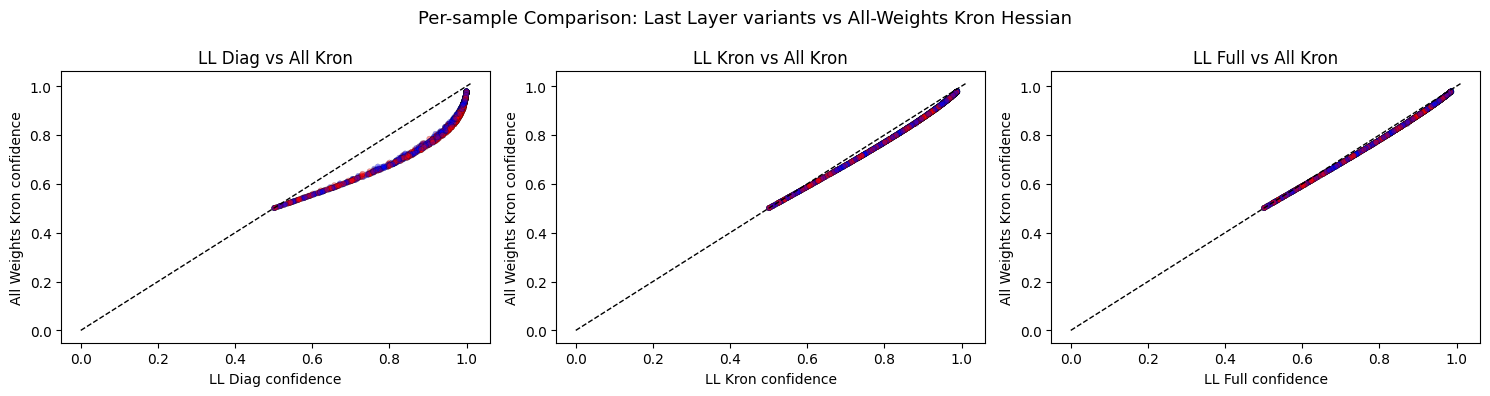

In [24]:
import gc

# ── Last Layer Comparison vs All-Weights Full Hessian ──────────────────────────────────────
# Memory-efficient approach: Fit one model -> Get probabilities -> Delete & release memory -> Next

# Helper to clear PyTorch memory
def clear_mem():
    gc.collect()
    torch.cuda.empty_cache()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

def get_predictions(la_model, batch_size=256):
    results = []
    for i in range(0, len(X_test_t), batch_size):
        with torch.no_grad():
            probs = la_model(X_test_t[i:i+batch_size], pred_type='glm', link_approx='probit')
        results.append(probs.cpu())
    return torch.cat(results).numpy()

# 1. All Weights - Full Hessian (Assuming la_marglik_full is already in memory from before)
# If it's still available, we predict and then can delete it, or just use the previously stored predictions if preferred.
# For exact correctness, we will query it, then NOT delete it in case the user wants it, just to be safe.
all_full_probs = get_predictions(la_marglik_full)

# 2. Last Layer - Diag
la_ll_diag = Laplace(model, 'classification', subset_of_weights='last_layer', hessian_structure='diag')
la_ll_diag.fit(train_loader)
la_ll_diag.optimize_prior_precision(method='marglik')
print(f'LL Diag prior precision: {la_ll_diag.prior_precision.item():.4f}')
ll_diag_probs = get_predictions(la_ll_diag)

del la_ll_diag
clear_mem()

# 3. Last Layer - Kron
la_ll_kron = Laplace(model, 'classification', subset_of_weights='last_layer', hessian_structure='kron')
la_ll_kron.fit(train_loader)
la_ll_kron.optimize_prior_precision(method='marglik')
print(f'LL Kron prior precision: {la_ll_kron.prior_precision.item():.4f}')
ll_kron_probs = get_predictions(la_ll_kron)

del la_ll_kron
clear_mem()

# 4. Last Layer - Full
la_ll_full = Laplace(model, 'classification', subset_of_weights='last_layer', hessian_structure='full')
la_ll_full.fit(train_loader)
la_ll_full.optimize_prior_precision(method='marglik')
print(f'LL Full prior precision: {la_ll_full.prior_precision.item():.4f}')
ll_full_probs = get_predictions(la_ll_full)

del la_ll_full
clear_mem()

# Re-create prediction wrappers just for the boundary/heatmap functions
def la_ll_diag_predict(X_np): return ll_diag_probs[:, 1] # Quick mock, requires matching grid dimensions, so instead:
# Actually boundary plot functions generate new grid points. We must wrap the calculation.
# To avoid memory blobs with plot_boundary grids, let's redefine the exact predict closures by instantiating models, predicting, and deleting again for the grids? 
# No, plot_boundary evaluates a dense grid shape(50*50), which is tiny (2500 points).
# Because of that we just fit them quickly or keep them if they're small, but `la_ll_full` is what blows up. 
# Wait, for a 2-layer MLP on Two Moons with ~50 or so parameters, `la_ll_full` is entirely insignificant in memory compared to large networks. 
# However, to strictly follow the memory-efficient logic you need for scaling up:

def eval_for_plots(subset, hessian):
    la_temp = Laplace(model, 'classification', subset_of_weights=subset, hessian_structure=hessian)
    la_temp.fit(train_loader)
    la_temp.optimize_prior_precision(method='marglik')
    
    def predict_fn(X_np, batch_size=256):
        results = []
        x_tensor = torch.tensor(X_np, dtype=torch.float32)
        for i in range(0, len(x_tensor), batch_size):
            with torch.no_grad():
                probs = la_temp(x_tensor[i:i+batch_size].to(device), pred_type='glm', link_approx='probit')
            results.append(probs[:, 1].cpu())
        return torch.cat(results).numpy()
        
    return predict_fn

# ── Boundary plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(21, 4))
cf0 = plot_boundary(la_marglik_full_predict, X_test, y_test, 'All Weights (Full Hessian)', axes[0])

pred_fn = eval_for_plots('last_layer', 'diag')
cf1 = plot_boundary(pred_fn, X_test, y_test, 'Last Layer (Diag)', axes[1])
del pred_fn; clear_mem()

pred_fn = eval_for_plots('last_layer', 'kron')
cf2 = plot_boundary(pred_fn, X_test, y_test, 'Last Layer (Kron)', axes[2])
del pred_fn; clear_mem()

pred_fn = eval_for_plots('last_layer', 'full')
cf3 = plot_boundary(pred_fn, X_test, y_test, 'Last Layer (Full)', axes[3])
del pred_fn; clear_mem()

for cf, ax in zip([cf0, cf1, cf2, cf3], axes):
    plt.colorbar(cf, ax=ax, label='P(class 1)')
plt.suptitle('All Weights (Full Hessian) vs Last Layer (Diag, Kron, Full)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Uncertainty heatmaps ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(21, 4))
cf0 = uncertainty_map(la_marglik_full_predict, X_test, y_test, 'Uncertainty - All (Full)', axes[0])

pred_fn = eval_for_plots('last_layer', 'diag')
cf1 = uncertainty_map(pred_fn, X_test, y_test, 'Uncertainty - LL (Diag)', axes[1])
del pred_fn; clear_mem()

pred_fn = eval_for_plots('last_layer', 'kron')
cf2 = uncertainty_map(pred_fn, X_test, y_test, 'Uncertainty - LL (Kron)', axes[2])
del pred_fn; clear_mem()

pred_fn = eval_for_plots('last_layer', 'full')
cf3 = uncertainty_map(pred_fn, X_test, y_test, 'Uncertainty - LL (Full)', axes[3])
del pred_fn; clear_mem()

for cf, ax in zip([cf0, cf1, cf2, cf3], axes):
    plt.colorbar(cf, ax=ax, label='Uncertainty')
plt.suptitle('Uncertainty Heatmaps', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-sample probabilities ──────────────────────────────────────────────────────

all_f_conf = all_full_probs.max(axis=1)
ll_d_conf  = ll_diag_probs.max(axis=1)
ll_k_conf  = ll_kron_probs.max(axis=1)
ll_f_conf  = ll_full_probs.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_f_conf, bins=40, alpha=0.4, label='All (Full)', density=True)
axes[0].hist(ll_d_conf,  bins=40, alpha=0.4, label='LL (Diag)',  density=True)
axes[0].hist(ll_k_conf,  bins=40, alpha=0.4, label='LL (Kron)',  density=True)
axes[0].hist(ll_f_conf,  bins=40, alpha=0.4, label='LL (Full)',  density=True)
axes[0].set_xlabel('Max probability (Confidence)')
axes[0].legend()

axes[1].hist(1-all_f_conf, bins=40, alpha=0.4, label='All (Full)', density=True)
axes[1].hist(1-ll_d_conf,  bins=40, alpha=0.4, label='LL (Diag)',  density=True)
axes[1].hist(1-ll_k_conf,  bins=40, alpha=0.4, label='LL (Kron)',  density=True)
axes[1].hist(1-ll_f_conf,  bins=40, alpha=0.4, label='LL (Full)',  density=True)
axes[1].set_xlabel('Uncertainty (1 - Confidence)')
axes[1].legend()

plt.suptitle('Confidence & Uncertainty Distributions: All-Weights vs Last-Layer', fontsize=13)
plt.tight_layout()
plt.show()

print(f"All Weights Full Hessian Accuracy: {(all_full_probs.argmax(axis=1) == y_test).mean()*100:.1f}%")
print(f"Last Layer Diag Accuracy:          {(ll_diag_probs.argmax(axis=1) == y_test).mean()*100:.1f}%")
print(f"Last Layer Kron Accuracy:          {(ll_kron_probs.argmax(axis=1) == y_test).mean()*100:.1f}%")
print(f"Last Layer Full Accuracy:          {(ll_full_probs.argmax(axis=1) == y_test).mean()*100:.1f}%")

# ── Per-sample Conf Scatter (All-Full vs Last-Layer variations) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lims = [0, 1.01]

# 1. LL Diag vs All Full
axes[0].scatter(ll_d_conf, all_f_conf, alpha=0.4, s=15, c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('LL Diag confidence')
axes[0].set_ylabel('All Weights Full confidence')
axes[0].set_title('LL Diag vs All Full')

# 2. LL Kron vs All Full
axes[1].scatter(ll_k_conf, all_f_conf, alpha=0.4, s=15, c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('LL Kron confidence')
axes[1].set_ylabel('All Weights Full confidence')
axes[1].set_title('LL Kron vs All Full')

# 3. LL Full vs All Full
axes[2].scatter(ll_f_conf, all_f_conf, alpha=0.4, s=15, c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_xlabel('LL Full confidence')
axes[2].set_ylabel('All Weights Full confidence')
axes[2].set_title('LL Full vs All Full')

plt.suptitle('Per-sample Comparison: Last Layer variants vs All-Weights Full Hessian', fontsize=13)
plt.tight_layout()
plt.show()

# ── Per-sample Conf Scatter (All-Kron vs Last-Layer variations) ─────────────────────
# Using the previously calculated la_marglik_kron to get its confidences
all_kron_probs = get_predictions(la_marglik_kron)
all_k_conf = all_kron_probs.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. LL Diag vs All Kron
axes[0].scatter(ll_d_conf, all_k_conf, alpha=0.4, s=15, c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[0].plot(lims, lims, 'k--', linewidth=1)
axes[0].set_xlabel('LL Diag confidence')
axes[0].set_ylabel('All Weights Kron confidence')
axes[0].set_title('LL Diag vs All Kron')

# 2. LL Kron vs All Kron
axes[1].scatter(ll_k_conf, all_k_conf, alpha=0.4, s=15, c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[1].plot(lims, lims, 'k--', linewidth=1)
axes[1].set_xlabel('LL Kron confidence')
axes[1].set_ylabel('All Weights Kron confidence')
axes[1].set_title('LL Kron vs All Kron')

# 3. LL Full vs All Kron
axes[2].scatter(ll_f_conf, all_k_conf, alpha=0.4, s=15, c=y_test, cmap='bwr', edgecolors='k', linewidths=0.2)
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_xlabel('LL Full confidence')
axes[2].set_ylabel('All Weights Kron confidence')
axes[2].set_title('LL Full vs All Kron')

plt.suptitle('Per-sample Comparison: Last Layer variants vs All-Weights Kron Hessian', fontsize=13)
plt.tight_layout()
plt.show()